In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from google import genai
from google.genai import types

from dotenv import load_dotenv

load_dotenv()

client = genai.Client()
EMBED_MODEL = "gemini-embedding-2"


def _image_part(image_path: str) -> types.Part:
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at: {image_path}")

    ext = os.path.splitext(image_path)[1].lower()
    mime_type = "image/jpeg" if ext in [".jpg", ".jpeg"] else "image/png"

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    return types.Part.from_bytes(data=image_bytes, mime_type=mime_type)


def get_image_embedding(image_path: str) -> list[float]:
    """3072-d visual embedding via gemini-embedding-2 (no text task bias)."""
    response = client.models.embed_content(
        model=EMBED_MODEL,
        contents=[_image_part(image_path)],
    )
    return response.embeddings[0].values


async def get_image_embedding_async(image_path: str) -> list[float] | None:
    try:
        response = await client.aio.models.embed_content(
            model=EMBED_MODEL,
            contents=[_image_part(image_path)],
        )
        return response.embeddings[0].values
    except Exception as exc:
        print(f"Failed to embed {image_path}: {exc}")
        return None

In [2]:
DATA_PATH = Path("data/img-metadata-CC0-clean.csv")
SAMPLE_SIZE = 100
RANDOM_SEED = 42
CACHE_DIR = Path("data/embedding_sample")
DB_PATH = CACHE_DIR / "embeddings.npz"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH, low_memory=False)
sample = (
    data.dropna(subset=["image_web"])
    .sample(SAMPLE_SIZE, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)
sample[["accession_number", "title", "image_web"]].head()

,accession_number,title,image_web
0,1962.279.242.a,Mahrusa kills herself at the tomb of the king ...,https://openaccess-cdn.clevelandart.org/1962.2...
1,1921.965,The Early Plowman,https://openaccess-cdn.clevelandart.org/1921.9...
2,1952.260,Portrait Head of a Noble or Official,https://openaccess-cdn.clevelandart.org/1952.2...
3,1920.1975,Trial Piece Worked on Both Sides,https://openaccess-cdn.clevelandart.org/1920.1...
4,1982.179.47,Reynard the Fox: Reynard Promises Gifts to th...,https://openaccess-cdn.clevelandart.org/1982.1...


In [3]:
import urllib.request

from tqdm.contrib.concurrent import thread_map


def download_image(item):
    acc, url = item
    path = CACHE_DIR / f"{acc}.jpg"
    if path.exists():
        return acc, str(path)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as response:
            path.write_bytes(response.read())
        return acc, str(path)
    except Exception:
        return acc, None


tasks = list(sample[["accession_number", "image_web"]].itertuples(index=False, name=None))
download_results = thread_map(
    download_image,
    tasks,
    max_workers=16,
    desc="Downloading images",
)
paths = {acc: path for acc, path in download_results if path}
len(paths), len(sample) - len(paths)

/home/arjun/projects/ArtButSports/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(100, 0)

In [4]:
import asyncio

from tqdm.asyncio import tqdm_asyncio

MAX_EMBED_WORKERS = 8


async def _embed_record(row) -> dict | None:
    path = paths.get(row["accession_number"])
    if not path:
        return None

    vector = await get_image_embedding_async(path)
    if vector is None:
        return None

    return {
        "accession_number": row["accession_number"],
        "title": row["title"],
        "path": path,
        "vector": np.asarray(vector, dtype=np.float32),
    }


async def build_embedding_db(force_rebuild: bool = False) -> dict:
    if DB_PATH.exists() and not force_rebuild:
        db = np.load(DB_PATH, allow_pickle=True)
        return {
            "vectors": db["vectors"],
            "accession_numbers": db["accession_numbers"],
            "titles": db["titles"],
            "paths": db["paths"],
        }

    rows = [row for _, row in sample.iterrows() if paths.get(row["accession_number"])]
    semaphore = asyncio.Semaphore(MAX_EMBED_WORKERS)

    async def bounded_embed(row):
        async with semaphore:
            return await _embed_record(row)

    results = await tqdm_asyncio.gather(
        *[bounded_embed(row) for row in rows],
        desc="Embedding images",
    )
    records = [r for r in results if r is not None]

    if not records:
        raise RuntimeError("No embeddings were generated. Check API key and image paths.")

    vectors = np.stack([r["vector"] for r in records])
    # L2-normalize so dot product == cosine similarity
    vectors /= np.linalg.norm(vectors, axis=1, keepdims=True)

    accession_numbers = np.array([r["accession_number"] for r in records], dtype=object)
    titles = np.array([r["title"] for r in records], dtype=object)
    image_paths = np.array([r["path"] for r in records], dtype=object)

    np.savez(
        DB_PATH,
        vectors=vectors,
        accession_numbers=accession_numbers,
        titles=titles,
        paths=image_paths,
    )

    failed = len(rows) - len(records)
    if failed:
        print(f"Skipped {failed} image(s) due to missing paths or API errors.")

    return {
        "vectors": vectors,
        "accession_numbers": accession_numbers,
        "titles": titles,
        "paths": image_paths,
    }


db = await build_embedding_db(force_rebuild=False)
print(f"Stored {len(db['vectors'])} embeddings at {DB_PATH}")
print(f"Vector dims: {db['vectors'].shape[1]}")

Embedding images: 100%|██████████| 100/100 [00:18<00:00,  5.46it/s]

Stored 100 embeddings at data/embedding_sample/embeddings.npz
Vector dims: 3072


In [5]:
def search_similar(query_image: str, top_k: int = 5) -> pd.DataFrame:
    query_vec = np.asarray(get_image_embedding(query_image), dtype=np.float32)
    query_vec /= np.linalg.norm(query_vec)

    scores = db["vectors"] @ query_vec
    top_idx = np.argsort(scores)[::-1][:top_k]

    return pd.DataFrame(
        {
            "rank": range(1, len(top_idx) + 1),
            "accession_number": db["accession_numbers"][top_idx],
            "title": db["titles"][top_idx],
            "path": db["paths"][top_idx],
            "similarity": scores[top_idx],
        }
    )

,rank,accession_number,title,similarity
0,1,1922.175,Court Ladies Making Dolls,1.000000
1,2,1982.131,Windy Landscape with Sailboat,0.762811
2,3,1962.279.241.a,The king of Zabul sees Mahrusa from his palace...,0.757905
3,4,1962.279.125.b,"The merchant Mansur departs on a sea voyage, l...",0.753247
4,5,1921.1260.a,Kataoka Nizaemon VII and Ichikawa Yaozo III in...,0.749596


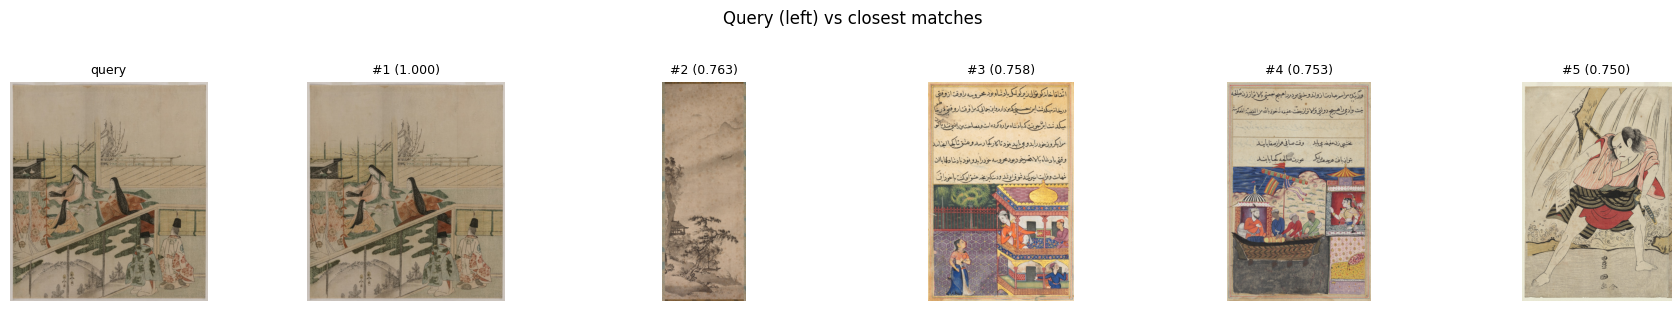

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set this to any local image path (inside or outside the mini db)
QUERY_IMAGE = str(db["paths"][99])  # default: first db image
TOP_K = 5

results = search_similar(QUERY_IMAGE, top_k=TOP_K)
display(results[["rank", "accession_number", "title", "similarity"]])

fig, axes = plt.subplots(1, TOP_K + 1, figsize=(3 * (TOP_K + 1), 3))
fig.suptitle("Query (left) vs closest matches", y=1.02)

axes[0].imshow(mpimg.imread(QUERY_IMAGE))
axes[0].set_title("query", fontsize=9)
axes[0].axis("off")

for i, (_, row) in enumerate(results.iterrows()):
    ax = axes[i + 1]
    ax.imshow(mpimg.imread(row["path"]))
    ax.set_title(f"#{row['rank']} ({row['similarity']:.3f})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()